<a href="https://colab.research.google.com/github/alicecongiu01-oss/EXERCISE-2/blob/main/EXERCISE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import dataset
import urllib.request

names_url = "https://raw.githubusercontent.com/Max1234-Ita/Liste/refs/heads/main/nomi_italiani.txt"
names = urllib.request.urlopen(names_url).read()
names = names.decode("utf-8")
names = names.splitlines()

In [2]:
#preprocessing
import re
names = [w.strip() for w in names]
names = [w.lower() for w in names]
names = [''.join(c for c in w if c.isalpha()) for w in names]

In [3]:
#dataset info
min_lenght = min(len(w) for w in names)
max_lenght = max(len(w) for w in names)
names_lenght = len(names)
print("Minumum Lenght:", min_lenght)
print("Maximum Lenght:", max_lenght)
print("Names Lenght:", names_lenght)

Minumum Lenght: 2
Maximum Lenght: 24
Names Lenght: 9133


In [4]:
import torch

In [5]:
#Initialise 27x27 tensor for bigram count
N = torch.zeros((27, 27), dtype = torch.int32)

In [6]:
#create stoi and itos dictionaries
chars = sorted(list(set("".join(names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

In [7]:
#training
for w in names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

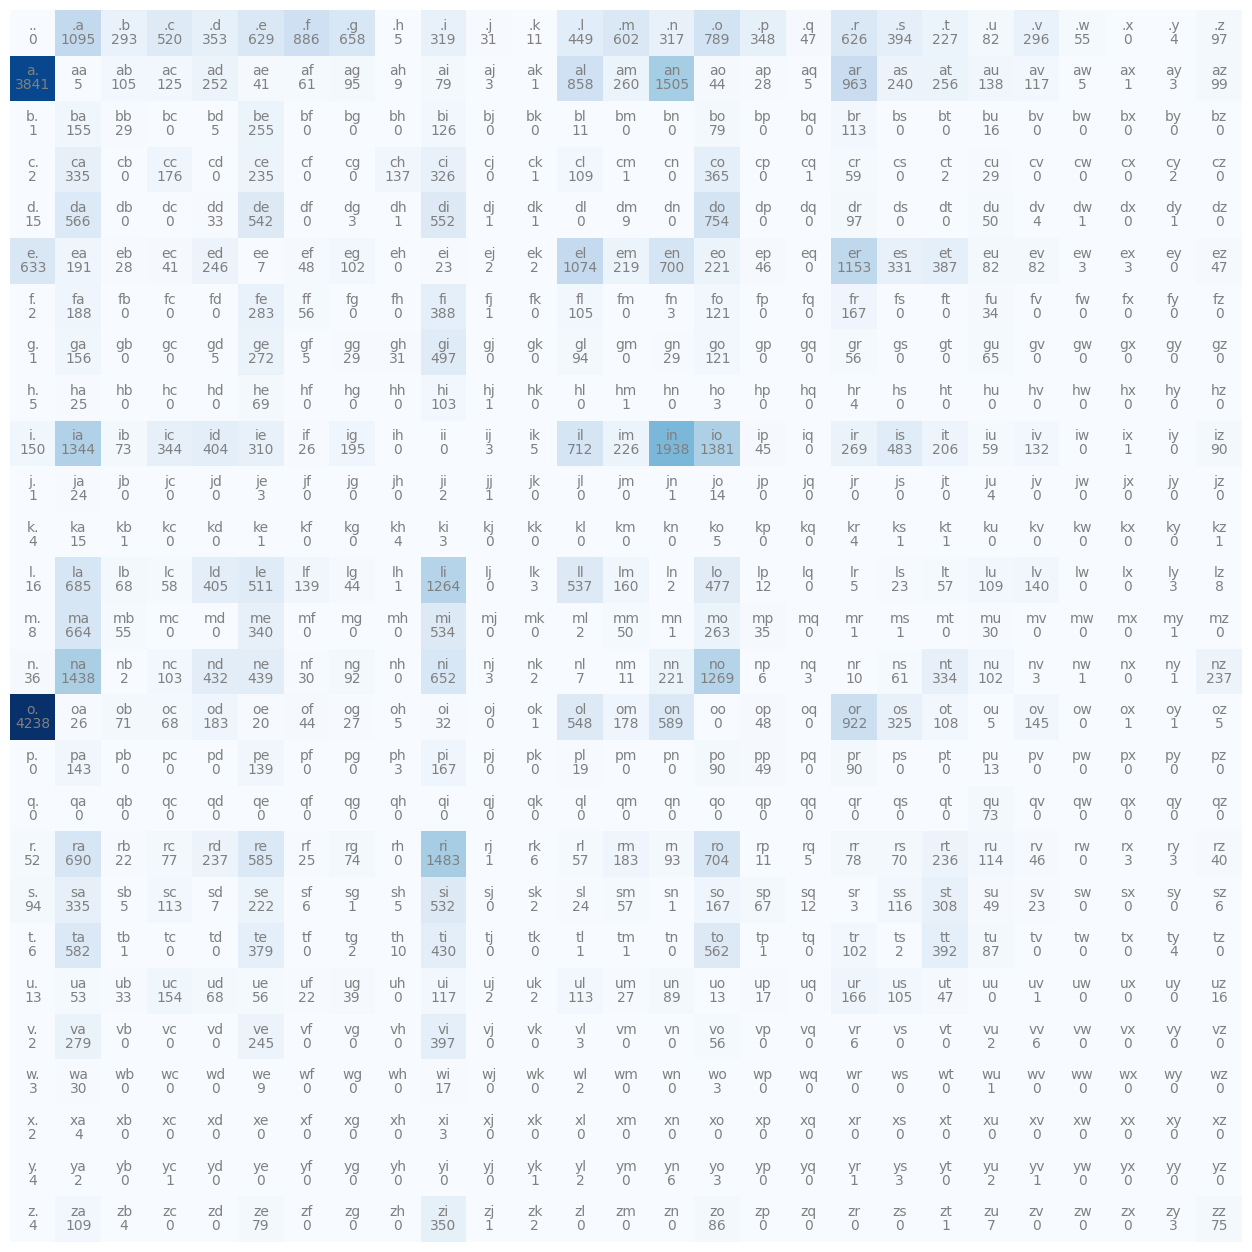

In [8]:
#visualise count matrix with matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [9]:
#probability normalisation and leplace smoothing
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [10]:
#generate 50 names with fixed seed
g = torch.Generator().manual_seed(2147483647)

for i in range(50):

  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cerida.
omo.
uriala.
varda.
vinimitta.
nollfanzka.
a.
oro.
ivaubrttarigotos.
mo.
fellio.
gia.
tedo.
eno.
mimesideueniavioniofolspidinidendorilascinsprdeletiligeniaisana.
ra.
dinerizimederu.
firitte.
ida.
belabevare.
miosttelicarilmenahia.
enanzalosilmio.
vazodio.
ceoralbitenimilageriseriazzeliallmanado.
findenisammio.
ma.
emintisicrficalcalio.
foro.
alve.
erzano.
nelo.
a.
rino.
alimana.
io.
sio.
gniclliawfa.
bo.
a.
lanoninutetora.
ridio.
rdunela.
me.
vilacca.
adana.
cch.
ghinndina.
milidimeco.
ro.
piauayx.


In [11]:
#evaluation: negative log likelihood
log_likelihood = 0.0
n = 0

for w in names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1


print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-160059.1562)
nll=tensor(160059.1562)
2.171353578567505
